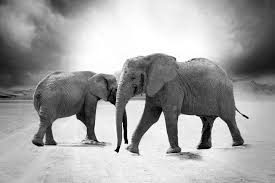

In [8]:
from PIL import Image
from IPython.display import display
img = Image.open("images.jpg")
display(img)

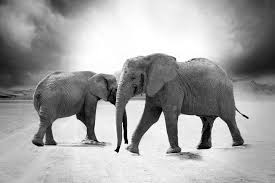

In [ ]:
import numpy as np # numerical python

def to_gray(img):
    if img.mode != "L":
        img = img.convert("L")
    return img

img = to_gray(img)
display(img)

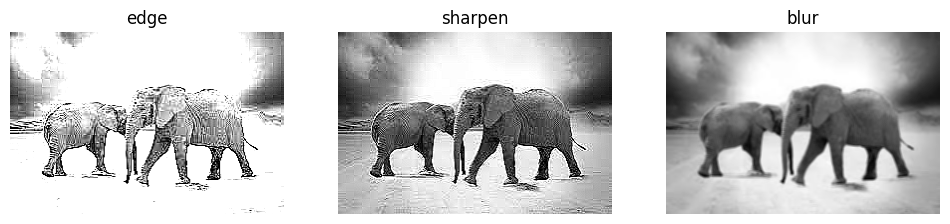

In [19]:
import matplotlib.pyplot as plt
def conv(img, filter):
    img = np.array(img, dtype=np.float32)
    h, w = img.shape
    k = filter.shape[0]
    pad = k // 2
    padded = np.pad(img, pad, mode="edge")
    out = np.zeros_like(img) # array of all 0s with same dimensions as padded
    for y in range(h):
        for x in range(w):
            patch = padded[y:y+k, x:x+k]
            out[y, x] = (patch * filter).sum()
    out = np.clip(out, 0, 255)
    return out

edge = np.array([[-1, -1, -1],
                 [-1, 10, -1], # change middle number to change sensitivity
                 [-1, -1, -1]], dtype=np.float32)
filtered_edge = conv(img, edge)

sharp = np.array([[0, -1, 0],
                 [-1, 5, -1],
                 [0, -1, 0]], dtype=np.float32)
filtered_sharp = conv(img, sharp)

blur = np.ones((3, 3), dtype=np.float32) * 1 / 9
filtered_blur = conv(img, blur)

fig, axs = plt.subplots(1, 3, figsize = (12, 3))
for ax, arr, title in zip(axs, [filtered_edge, filtered_sharp, filtered_blur], ["edge", "sharpen", "blur"]):
    ax.imshow(arr, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.show()

In [ ]:
fruits = ["apple", "bananananana", "coconut", "dragonfruit", "elderberry"]
fruits[1:3] # list of items from index 1 to 2 (3-1)

['bananananana', 'coconut']